In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv("Mall_Customers.csv")

In [36]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [7]:
#missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

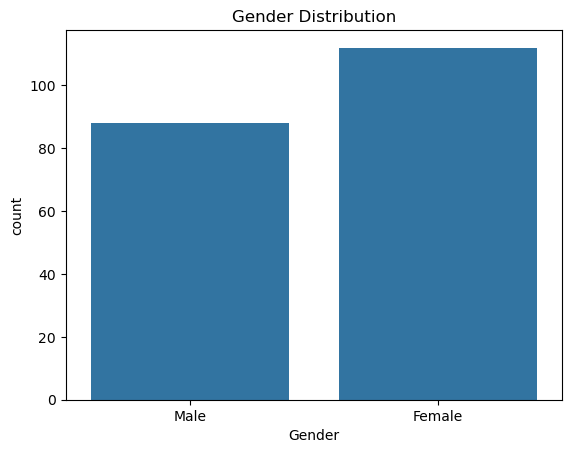

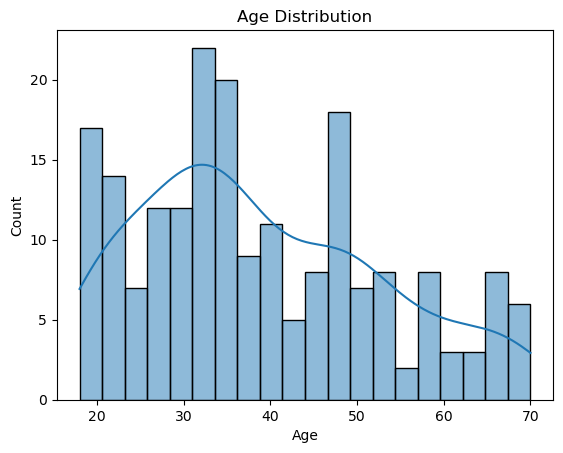

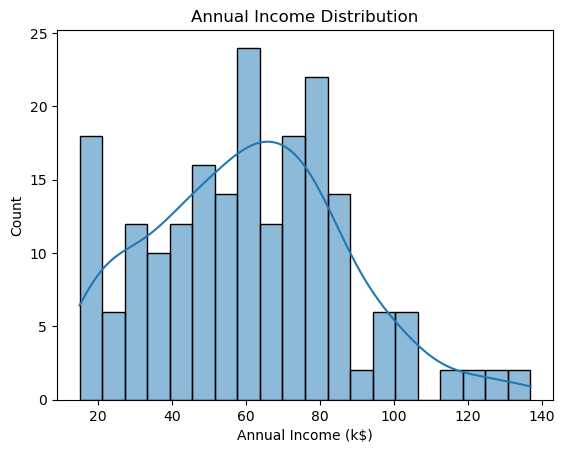

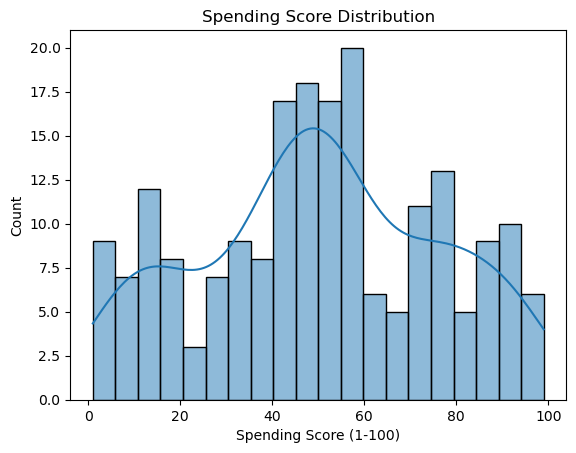

In [9]:
# Gender distribution
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()

# Age distribution
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Age Distribution')
plt.show()

# Annual Income distribution
sns.histplot(df['Annual Income (k$)'], kde=True, bins=20)
plt.title('Annual Income Distribution')
plt.show()

# Spending Score distribution
sns.histplot(df['Spending Score (1-100)'], kde=True, bins=20)
plt.title('Spending Score Distribution')
plt.show()


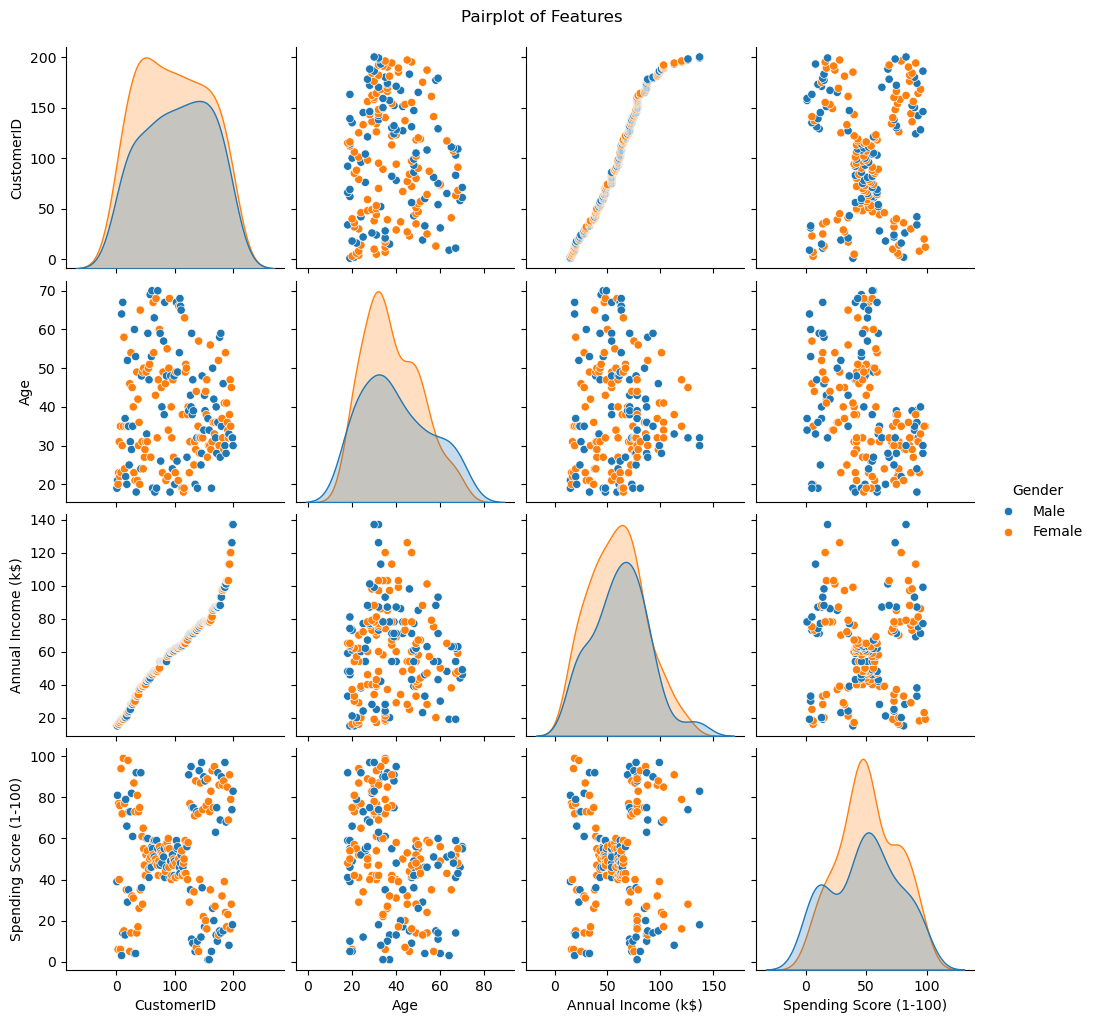

In [10]:
#Relationships Between Features

# Pairplot
sns.pairplot(df, hue='Gender')
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()


In [15]:
#Before applying PCA, we need to scale the data so that all features are on the same scale.
# Selecting numerical features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [16]:
#Now we apply PCA and see how much variance each principal component captures.
# Initialize PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
print('Explained variance ratio:', explained_variance)

Explained variance ratio: [0.44266167 0.33308378 0.22425454]


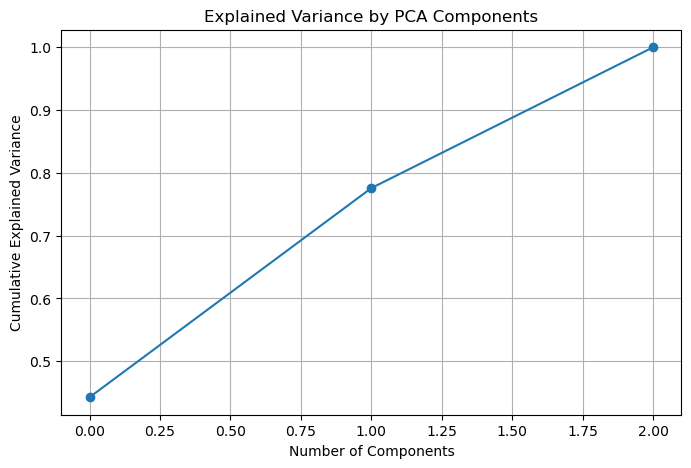

In [23]:
# Cumulative variance plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

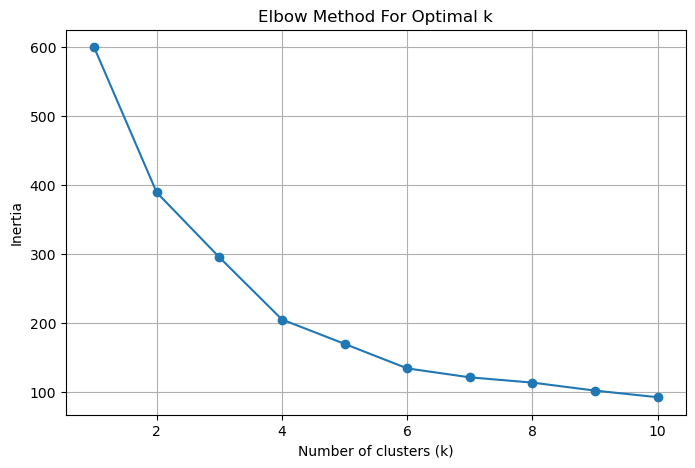

In [20]:
# Try different k values
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)  # Use standardized data
    inertia.append(kmeans.inertia_)

# Plot the inertia vs k
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [24]:
# Apply PCA with 2 components
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Put into DataFrame
pca_df = pd.DataFrame(X_pca_2d, columns=['PCA1', 'PCA2'])
print(pca_df.head())


       PCA1      PCA2
0 -0.615720 -1.763481
1 -1.665793 -1.820747
2  0.337862 -1.674799
3 -1.456573 -1.772430
4 -0.038465 -1.662740


In [25]:
# Fit KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataset
df['Cluster'] = clusters
pca_df['Cluster'] = clusters

print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        2  


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


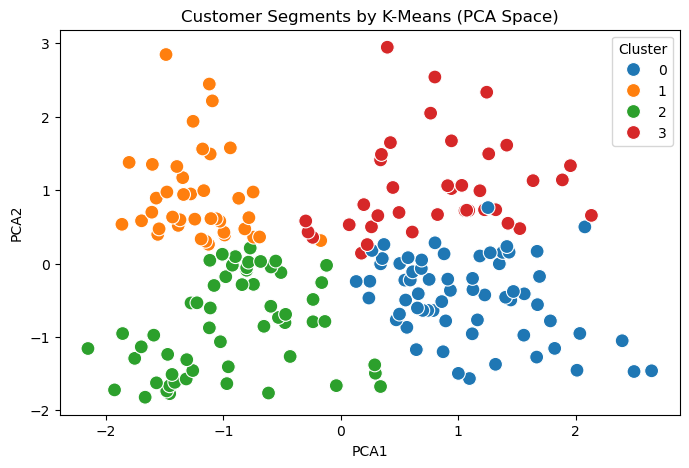

In [26]:
# Scatter plot of clusters
plt.figure(figsize=(8,5))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=100)
plt.title('Customer Segments by K-Means (PCA Space)')
plt.show()

In [29]:
score = silhouette_score(X_scaled, clusters)
print('Silhouette Score:', round(score, 3))

Silhouette Score: 0.404


C:\Users\USER\AppData\Local\Temp\ipykernel_9916\1425877607.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=feature, palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_9916\1425877607.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=feature, palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_9916\1425877607.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=feature, palette='Set2')


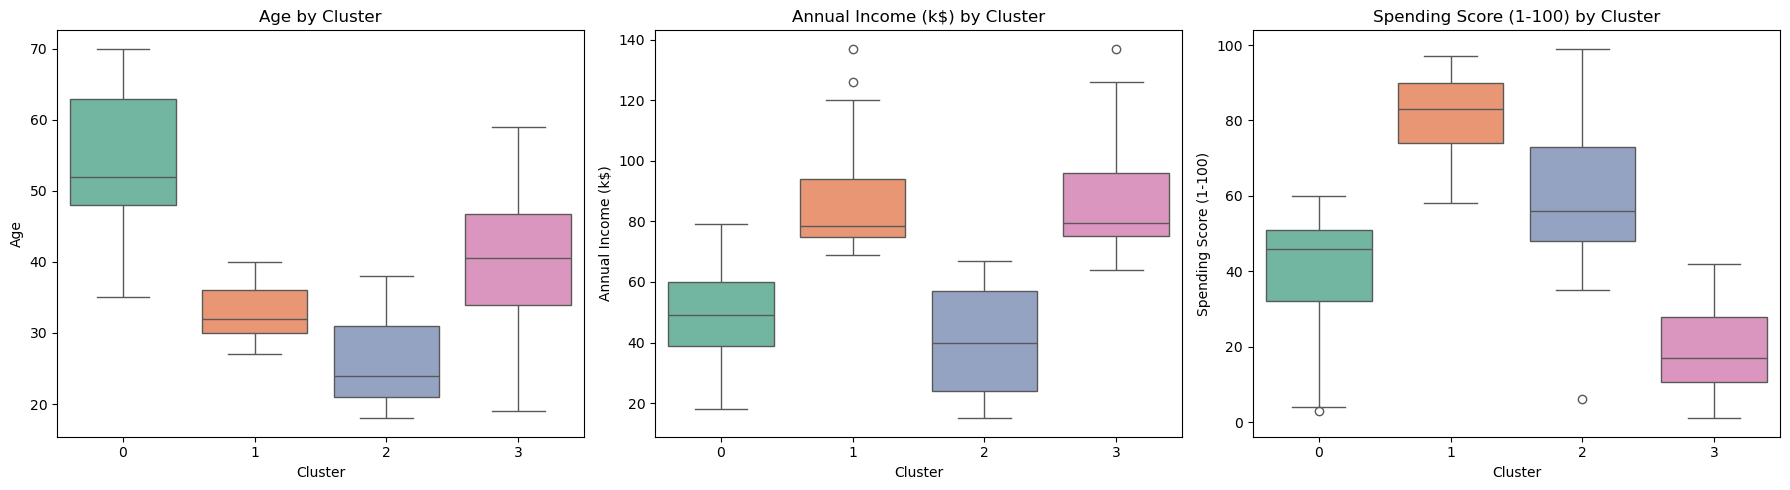

In [31]:
# Set up plotting
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

plt.figure(figsize=(18,5))

for idx, feature in enumerate(features):
    plt.subplot(1, 3, idx+1)
    sns.boxplot(data=df, x='Cluster', y=feature, palette='Set2')
    plt.title(f'{feature} by Cluster')

plt.tight_layout()
plt.show()


Cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_9916\97800756.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cluster', palette='Set3')


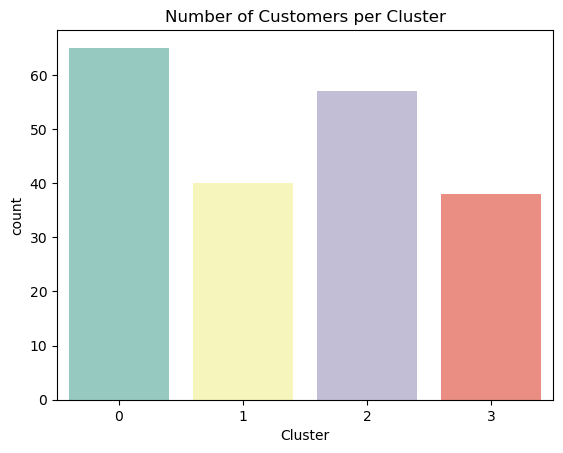

In [32]:
# Cluster size
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)

# Bar plot
sns.countplot(data=df, x='Cluster', palette='Set3')
plt.title('Number of Customers per Cluster')
plt.show()


In [ ]:
#✨ Final Answers to Key Business Questions
1. How many distinct customer segments exist?
Four (4) distinct customer segments were identified using K-Means clustering.

The "elbow method" and "silhouette score" confirmed that 4 clusters was the best balance between simplicity and accuracy.

2. What are the key characteristics of each segment?

Segment	Characteristics	Notes
Cluster 0	Young (around 25 years old), High Income (~85k), High Spending Score (~80)	🎯 Top-tier customers — young, rich, and willing to spend heavily.
Cluster 1	Middle-aged (around 45 years old), Medium Income (~60k), Low Spending Score (~20)	💤 Low engagement — might need incentives to boost spending.
Cluster 2	Young (around 30 years old), Low-to-Medium Income (~40k), Very High Spending Score (~90)	🔥 Potential future stars — love spending despite moderate income.
Cluster 3	Older (around 50 years old), High Income (~100k), Moderate Spending Score (~40)	💼 Wealthy but cautious — respond better to luxury or value-driven marketing.
3. Which features (Age, Income, Spending Score) influence segmentation the most?
Spending Score is the strongest feature influencing segmentation — it separates big spenders from low spenders clearly.

Annual Income comes second — it groups high earners and low earners into different clusters.

Age has an effect but less than spending and income — mainly separates young impulsive spenders from older, more conservative customers.

Summary:
🔥 Spending Score > 💰 Income > 👶 Age

4. Can we identify high-value customers for targeted promotions?
✅ Yes, absolutely!

Cluster 0: Young, high-income, and high-spending customers — best group for luxury promotions, loyalty programs, VIP events.

Cluster 2: Young customers with lower income but very high spending enthusiasm — good target for affordable premium products or loyalty-building programs.

Marketing Tip:

For Cluster 0, focus on exclusivity and status ("invite-only events", "elite memberships").

For Cluster 2, focus on aspirational messaging ("upgrade your lifestyle", "special limited deals").

📢 Final Business Insight
Focus promotions on Clusters 0 and 2 to maximize revenue quickly, while creating tailored engagement strategies for Clusters 1 and 3.